## Setup: Only for Google Colab

**If you are running this notebook locally, skip this section** — the helper files and data already sit next to the notebook.

On Google Colab, run the cells below first. They fetch the helper modules and data for this project from the [BAMB2026 GitHub repository](https://github.com/bambschool/BAMB2026) and install the required packages. Check the left sidebar afterwards to confirm the files appeared, and make sure there are no download or installation errors.

In [ ]:
# Base path to the Module 4 files in the BAMB2026 GitHub repository
RAW = 'https://raw.githubusercontent.com/bambschool/BAMB2026/main/Module%204/'

# Helper modules
py_files = ['environments.py', 'models.py', 'recovery.py']
for f in py_files:
    !wget -q -O {f} "{RAW}{f}"

print('Downloads complete.')

In [ ]:
# Install required packages
!pip install -q numpy scipy matplotlib gymnasium

That is everything Colab needs. The rest of the notebook runs identically on Colab and locally. **Now continue below.**

---

# Day 2 Track 1: Designing Experiments for Model Discriminability

**Prepared by:** Charley M. Wu (TU Darmstadt; [hmc-lab.com](https://hmc-lab.com/)) for the 2026 Barcelona Summer School for Advanced Modeling of Behavior (BAMB; https://www.bambschool.org/)

**Module 4 // Day 2 // Track 1**


---

Yesterday you implemented **DINER** (Dyna with Inferred Nonparametric Environment Recurrence) and watched it handle non-stationary environments.  Today you take on a harder, more scientifically interesting challenge: **designing a robust experiment**.

Your task is to find a set of maze environments and environmental dynamics such that, if you simulated synthetic participants under three competing models (DINER vs. Fresh-start DYNA-Q vs. Persistent DYNA-Q), you would be able to reliably tell them apart by their behavior. 

Following [Wilson & Collins (eLife 2019)](https://elifesciences.org/articles/49547), the two gold-standard checks are:

| Check | Question answered |
|---|---|
| **Model recovery** | If data was generated by model A, does fitting all candidate models correctly identify A? |
| **Parameter recovery** | Will we estimate similar parameters as those used to simulate data? |

**What you'll do today:**
1. **Design environments**. Choose maze layouts and dynamics that maximise model discriminability
2. **Simulate models**. Simulate virtual participant data for each model
3. **Estimate models and assess recovery**. Fit models to simulated data, then produce parameter and model recovery plots
4. **Iterate**. Tweak your design until recovery is reliable
5. **Explore**. Expand the design space, connecting back to Day 1 Block 2 proposals for how to extend the model and task

You have the entire day. Expect 2–4 design iterations before finding one that reliably works and will allow you answer an interesting open question in science.


## Setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

from environments import (
    create_custom_environment,
    generate_sticky_env_sequence,
)
from recovery import (
    softmax_probs,
    simulate_diner,
    simulate_fresh_start,
    simulate_persistent,
    loglik_diner,
    loglik_fresh_start,
    loglik_persistent,
    fit_model,
    fit_diner_full,
    compute_bic,
    compute_cluster_assignments,
)

plt.rcParams.update({'font.size': 12, 'axes.spines.top': False, 'axes.spines.right': False})
rng = np.random.default_rng(2026) # Set random seed for reproducibility

---
## 1. Designing Environments

For model recovery to work, the three models must produce **different behavioural signatures**. Think about what each model predicts:

- **DINER** gets better on repeat visits to the *same* environment, but starts from scratch when visiting a *new* one for the first time. Its learning curves should show fast improvement within a cluster, and a dip when switching to a new environment, with fast re-learning when returning.
- **Fresh-start** never improves across episodes, since every episode looks like the first visit. Returns should stay low and noisy throughout.
- **Persistent** improves monotonically but gets confused when environments switch, because it blends Q-values from conflicting environments.

For these signatures to be distinguishable, your environments should satisfy some key criterion:

| Criterion | Why it matters |
|---|---|
| **Divergent policies** | The best path in env A should be useless (or actively harmful) in env B |
| **Non-trivial path length** | Very short paths will make all agents look identical once they've solved the maze |
| **Probe-distinguishable start states** | DINER uses a set of start-state transitions to determine which environment it's in. This requires wall structure near the start position to differ across environments |

**Exercise 1.** Look at the three default environments below. Can you construct your own mazes requiring divergent optimal paths? Can you soften the requirement that they are all distinguishable from the very first state?  
**Exercise 2.** *(Stretch goal)* Add a 4th environment. Does having more environments make model recovery easier or harder?

In [2]:
# === DESIGN YOUR ENVIRONMENTS HERE ===
# Rules:
#   A = agent start (exactly one per map)
#   G = goal (exactly one per map)
#   # = wall (impassable)
#   . = open cell
#   Grid must be square (10×10 shown here)
#
# Design goal: environments with DIVERGENT optimal paths
# so that knowledge from one environment is useless (or harmful) in another.

env_configs = {
    'env_a': '''
    A . . . . . . . . G
    # . # # . . . . . .
    . . . # . . . . . .
    . . . # . . . . . .
    . . . # . . . . . .
    . . . # . . . . . .
    . . . # . . . . . .
    . . . # # # # # . #
    . . . . . . . . . .
    . . . . . . . . . .''',

    'env_b': '''
    A # . . . . . . . .
    . . . . . . . . . .
    . # . . . . . . . .
    . # # # # # # . . .
    . . . . . . # . . .
    . . . . . . # . . .
    . . . . . . # . . .
    . . . . . . # # . #
    . . . . . . . . . .
    G . . . . . . . . .''',

    'env_c': '''
    A . . . . . . . . .
    . . . . . . . . . .
    . . . . . . . . . .
    # # # # # # # # . .
    . . . . . . . . . .
    . . . . . . . . . .
    . . # # # # # # # #
    . . . . . . . . . .
    . . . . . . . . . .
    . . . . . . . . . G''',
}
# ======================================

envs = {
    name: create_custom_environment(ascii_map=ascii_map, max_steps=200).build()
    for name, ascii_map in env_configs.items()
}
env_names = list(envs.keys())
print('Environments built:', env_names)

Environments built: ['env_a', 'env_b', 'env_c']


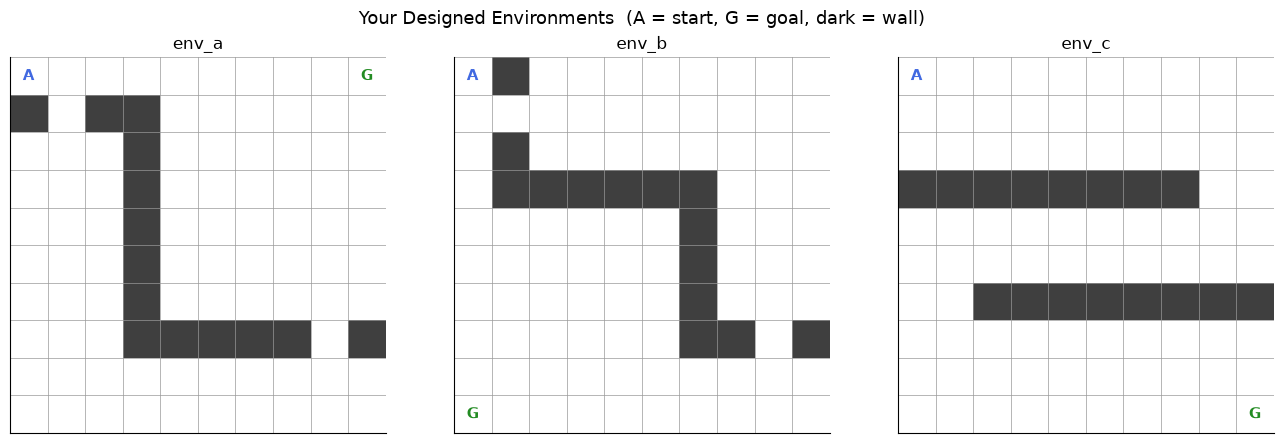

Maze sizes: {'env_a': '10×10', 'env_b': '10×10', 'env_c': '10×10'}
Obstacle counts: {'env_a': 14, 'env_b': 14, 'env_c': 16}


In [3]:
# Visualise your environments as grid maps
def plot_env(ax, env, title=''):
    """Draw a gridworld environment using the env's internal attributes."""
    size = env.size
    img = np.ones((size, size, 3))  # white background
    for r, c in env.obstacles:
        img[r, c] = [0.25, 0.25, 0.25]  # dark grey walls

    ax.imshow(img, interpolation='nearest', extent=[-0.5, size - 0.5, size - 0.5, -0.5])

    # Draw grid lines
    for i in range(size + 1):
        ax.axhline(i - 0.5, color='#999', linewidth=0.5)
        ax.axvline(i - 0.5, color='#999', linewidth=0.5)

    # Mark start and goal
    sr, sc = env.start_pos
    gr, gc = env.goal_pos
    ax.text(sc, sr, 'A', ha='center', va='center', fontsize=11, fontweight='bold',
            color='royalblue')
    ax.text(gc, gr, 'G', ha='center', va='center', fontsize=11, fontweight='bold',
            color='forestgreen')

    ax.set_xlim(-0.5, size - 0.5)
    ax.set_ylim(size - 0.5, -0.5)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(title, fontsize=12)


fig, axes = plt.subplots(1, len(env_names), figsize=(4.5 * len(env_names), 4.5))
if len(env_names) == 1:
    axes = [axes]
for ax, name in zip(axes, env_names):
    plot_env(ax, envs[name], title=name)

plt.suptitle('Your Designed Environments  (A = start, G = goal, dark = wall)', fontsize=13)
plt.tight_layout()
plt.show()

print('Maze sizes:', {name: f'{envs[name].size}×{envs[name].size}' for name in env_names})
print('Obstacle counts:', {name: len(envs[name].obstacles) for name in env_names})

In [4]:
# Separability check: can DINER's probe fingerprint distinguish all environments?
# If two environments produce identical probe signatures, DINER cannot separate them.
alpha_value = 1.0 #<-- tweak alpha to see how it affects the clustering results
probe_limit = 10 #<-- increase probe_limit if the agent requires more distant state visitations to distinguish environments

# Round-robin sequence: visit each environment multiple times
test_seq = env_names * 5  # 5 complete round-robins
assignments = compute_cluster_assignments(test_seq, envs, crp_alpha=alpha_value, n_probe=probe_limit, seed=2026)

print('Probe-based cluster assignments (round-robin visit, crp_alpha=1.0):')
for ep, (name, k) in enumerate(zip(test_seq, assignments)):
    marker = '✓' if ep >= len(env_names) else ' '
    print(f'  {marker} Episode {ep:2d}: {name:8s} → cluster {k}')

n_found = len(set(assignments))
n_expected = len(env_names)
print(f'\nClusters found: {n_found}  (expected: {n_expected})')
if n_found == n_expected:
    print('✓ All environments are probe-distinguishable!')
elif n_found < n_expected:
    print(f'✗ Only {n_found}/{n_expected} clusters were correctly identified.')
    print('  Fix: increase probe_limit or modify wall placement near the start position (A) make them more distinguishable')

else:
    print(f'✗ Over-splitting: {n_found} clusters for {n_expected} environments.')
    print('  Fix: reduce crp_alpha, or check if the variability of probe transitions (if added) is causing false splits.')

Probe-based cluster assignments (round-robin visit, crp_alpha=1.0):
    Episode  0: env_a    → cluster 0
    Episode  1: env_b    → cluster 1
    Episode  2: env_c    → cluster 2
  ✓ Episode  3: env_a    → cluster 0
  ✓ Episode  4: env_b    → cluster 1
  ✓ Episode  5: env_c    → cluster 2
  ✓ Episode  6: env_a    → cluster 0
  ✓ Episode  7: env_b    → cluster 1
  ✓ Episode  8: env_c    → cluster 2
  ✓ Episode  9: env_a    → cluster 0
  ✓ Episode 10: env_b    → cluster 1
  ✓ Episode 11: env_c    → cluster 2
  ✓ Episode 12: env_a    → cluster 0
  ✓ Episode 13: env_b    → cluster 1
  ✓ Episode 14: env_c    → cluster 2

Clusters found: 3  (expected: 3)
✓ All environments are probe-distinguishable!


---
## 2. Designing Experimental Dynamics

The design of the mazes is only half the story. The *sequence* of environments also matters a lot for model discriminability, since this is where model assumptions differ the most. Here are some parameters that could be tweaked.

**`stay_prob`** $\in [0–1]$: probability of staying in the same environment for the next episode.
- High (>0.9): long runs per environment, create plenty of time to learn Q-values, but few cluster transitions, so DINER's advantage over Persistent is smaller
- Low (<0.4): frequent switches, create more opportunities for context-switching to pay off, but each cluster is visited only briefly

**`n_episodes`**: total data collected per participant. More episodes → more stable parameter estimates, but also longer experiments.

### Real-world timing constraints

Before setting these values, think carefully about what is realistic for a real participant. If each maze episode takes roughly **60–90 seconds** (including thinking time and movement), and you add ~5 minutes for consent and tutorial:

| Design | Episodes | Approx. task time | Total with admin |
|---|---|---|---|
| Light | 20 | ~20–30 min | ~25–35 min ✓ |
| Standard | 30 | ~30–45 min | ~35–50 min ✓ |
| Intensive | 60 | ~60–90 min | ~65–95 min ✗ too long |

A good target is **20–40 minutes total** (including consent and tutorial). Beyond this, attention and motivation start to drift, which adds noise to the data and makes parameter estimation less reliable.

> **Design trade-off:** More episodes improve recovery quality, but hit a ceiling once the agent has reliably solved each environment. Increasing episode *difficulty* (longer paths, more walls) can stretch out the learning curve and give more useful data per episode, without requiring more episodes. We can also have multiple blocks of the experiment, with each block starting from a new set of mazes, allowing for increased contributions of the early, potentially more distinguishable stages of learning. 

**Exercise 2.1.** With `stay_prob = 0.8`, the expected run length per environment is $1/(1 - 0.8) = 5$ episodes. What is the expected run length with `stay_prob = 0.5`? With `stay_prob = 0.95`?  
**Exercise 2.2.** Make a prediction: what `stay_prob` will make model recovery *hardest*? Why? (Hint: think about when DINER, Fresh-start, and Persistent would produce the most similar trajectories.)  
**Exercise 2.3.** Given the timing constraints above, what is the maximum number of episodes you can realistically collect? How does this affect your model recovery strategy?


Sequence: 30 episodes, stay_prob=0.8
Episodes per environment: {'env_a': 4, 'env_c': 14, 'env_b': 12}
Run length: mean=4.3, max=6, theory=5.0  |  switches: 6


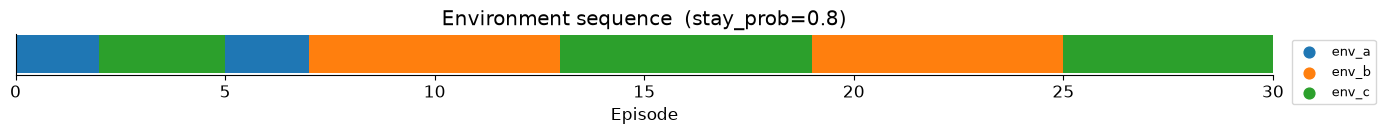

In [5]:
# === DESIGN YOUR EXPERIMENTAL DYNAMICS ===
N_EPISODES  = 30    # total episodes per simulated 'participant'
STAY_PROB   = 0.80  # probability of staying in the same environment

env_sequence = generate_sticky_env_sequence(env_names, N_EPISODES, stay_prob=STAY_PROB, seed=2026)

# Summary statistics
counts = Counter(env_sequence)
print(f'Sequence: {N_EPISODES} episodes, stay_prob={STAY_PROB}')
print('Episodes per environment:', dict(counts))

runs, cur, length = [], env_sequence[0], 1
for e in env_sequence[1:]:
    if e == cur:
        length += 1
    else:
        runs.append(length); cur, length = e, 1
runs.append(length)
print(f'Run length: mean={np.mean(runs):.1f}, max={max(runs)}, '
      f'theory={1/(1-STAY_PROB):.1f}  |  switches: {len(runs)-1}')

# Visualise the sequence
env_color = {name: c for name, c in
             zip(env_names, ['tab:blue', 'tab:orange', 'tab:green', 'tab:purple'])}
fig, ax = plt.subplots(figsize=(14, 1.5))
for ep, name in enumerate(env_sequence):
    ax.barh(0, 1, left=ep, color=env_color[name], edgecolor='none', height=1)
for name, c in env_color.items():
    ax.scatter([], [], color=c, s=60, label=name)
ax.set_xlim(0, N_EPISODES); ax.set_yticks([]); ax.set_xlabel('Episode')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)
ax.set_title(f'Environment sequence  (stay_prob={STAY_PROB})')
plt.tight_layout(); plt.show()


---
## 3. From ε-greedy to Softmax

We will now swap all three models to use **softmax** policy instead of ε-greedy:

$$
P(a \mid s) = \frac{\exp(Q(s,a) / \tau)}{\sum_{a'} \exp(Q(s,a') / \tau)}
$$

This will improve our ability to fit models to data. ε-greedy tends to create a piecewise-flat likelihood landscape (i.e., gradients are often exactly zero), making optimisation somewhat unreliable. Softmax produces a smoother, more differentiable likelihood surface in the space of model parameters.

Softmax samples actions proportional to the Q-values, with relative differences exaggerated via exponentiation. The temperature parameter τ further tweaks the amount of stochasticity in the policy:
- **High τ** → nearly uniform probabilities (random-looking exploration)
- **Low τ** → nearly deterministic (greedy exploitation)

Fresh-start and Persistent each have three  free parameters $(\eta, \tau, \gamma)$. DINER has four free parameters $(\eta, \tau, \gamma, \alpha)$, where $\eta$ is the learning rate,  $\tau$ is the softmax temperature, $\gamma$ controls future-reward discounting, and $\alpha$ controls how readily new environment clusters are opened. When comparing models with BIC, DINER incurs a larger parameter penalty ($k=4$ vs $k=3$), so it must achieve meaningfully better fit to win.

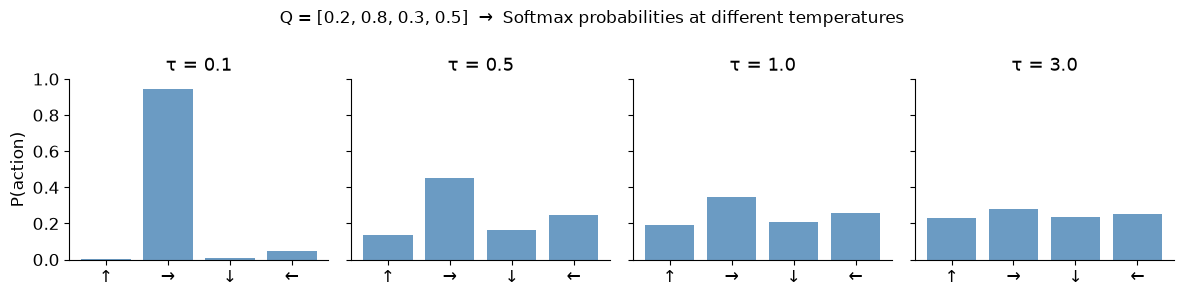

In [6]:
# See softmax in action
q_example = np.array([0.2, 0.8, 0.3, 0.5])  # Q-values for 4 actions

temperatures = [0.1, 0.5, 1.0, 3.0]
fig, axes = plt.subplots(1, 4, figsize=(12, 3), sharey=True)
for ax, tau in zip(axes, temperatures):
    probs = softmax_probs(q_example, tau)
    ax.bar(['↑', '→', '↓', '←'], probs, color='steelblue', alpha=0.8)
    ax.set_title(f'τ = {tau}', fontsize=13)
    ax.set_ylim(0, 1)
    ax.set_ylabel('P(action)' if ax is axes[0] else '')
fig.suptitle('Q = [0.2, 0.8, 0.3, 0.5]  →  Softmax probabilities at different temperatures', fontsize=12)
plt.tight_layout(); plt.show()

---
## 4. Simulating Data from Each Model

To test model recovery, we need to generate synthetic behavioural trajectories — one dataset per model. The key question is: **what assumptions does each model make about how Q-values persist across episodes?**

| Model | Q-table rule | Simulator |
|---|---|---|
| **DINER** | One Q-table per inferred cluster; resets only when *opening a new cluster* | `simulate_diner(...)` |
| **Fresh-start** | Q-table resets to zero at the start of **every** episode; nothing carries over | `simulate_fresh_start(...)` |
| **Persistent** | One shared Q-table accumulates across **all** episodes; nothing is forgotten | `simulate_persistent(...)` |

Each simulator in `recovery.py` implements the respective model and can be run on the same environment sequence, making it easy to compare their trajectories side-by-side.

**Exercise 4.1.** After running the cells below, compare the three learning curves. Which model improves fastest early on? Which improves most steadily over all episodes?  
**Exercise 4.2.** With `stay_prob=0.5` (fast switching), do the curves look more or less similar? Why?

> **Technical note.** You might wonder whether you could simulate Fresh-start or Persistent data by running DINER and then overriding its cluster assignments (e.g., forcing all episodes to cluster 0 to "simulate" Persistent). This will not work. The trajectories still come from DINER's Q-table management logic, with only the label changing. Thus, it is necessary to use the respective simulator functions to implement the correct Q-table logic for each model.


In [7]:
# ── Free parameters (to be estimated by the model) ────────────────────────────
TRUE_ETA   = 0.30   # learning rate η        ∈ (0, 1]
TRUE_TAU   = 0.50   # softmax temperature τ  > 0
TRUE_GAMMA = 0.95   # discount factor γ      ∈ (0, 1)
TRUE_ALPHA = 1.0    # CRP concentration α    > 0  (DINER only)

# ── Fixed parameters (given to the model; not estimated) ──────────────────────
PLANNING = 5    # Dyna planning sweeps per real step
N_PROBE  = 10   # probe transitions used to fingerprint environments

print('Free parameters (to be recovered):')
print(f'  η (learning rate)      = {TRUE_ETA}')
print(f'  τ (softmax temperature)= {TRUE_TAU}')
print(f'  γ (discount factor)    = {TRUE_GAMMA}')
print(f'  α (CRP concentration)  = {TRUE_ALPHA}  [DINER only]')
print()
print('Fixed parameters (given, not estimated):')
print(f'  planning steps = {PLANNING}')
print(f'  probe steps    = {N_PROBE}')


Free parameters (to be recovered):
  η (learning rate)      = 0.3
  τ (softmax temperature)= 0.5
  γ (discount factor)    = 0.95
  α (CRP concentration)  = 1.0  [DINER only]

Fixed parameters (given, not estimated):
  planning steps = 5
  probe steps    = 10


In [8]:
# Simulate all three models on the SAME environment sequence
diner_returns, cluster_assignments, diner_trajs = simulate_diner(
    env_sequence, envs,
    crp_alpha=TRUE_ALPHA, eta=TRUE_ETA, gamma=TRUE_GAMMA,
    tau=TRUE_TAU, planning_steps=PLANNING, n_probe=N_PROBE, seed=2026,
)

fresh_returns, fresh_trajs = simulate_fresh_start(
    env_sequence, envs,
    eta=TRUE_ETA, gamma=TRUE_GAMMA, tau=TRUE_TAU, planning_steps=PLANNING, seed=2026,
)

persistent_returns, persistent_trajs = simulate_persistent(
    env_sequence, envs,
    eta=TRUE_ETA, gamma=TRUE_GAMMA, tau=TRUE_TAU, planning_steps=PLANNING, seed=2026,
)

print(f'DINER:       {N_EPISODES} episodes, {len(set(cluster_assignments))} clusters inferred')
print(f'Fresh-start: {N_EPISODES} episodes  (Q-table resets each episode)')
print(f'Persistent:  {N_EPISODES} episodes  (one shared Q-table)')
print()
print(f'Mean returns:  DINER={np.mean(diner_returns):.2f}   '
      f'Fresh: {np.mean(fresh_returns):.2f}   '
      f'Persistent: {np.mean(persistent_returns):.2f}')


DINER:       30 episodes, 3 clusters inferred
Fresh-start: 30 episodes  (Q-table resets each episode)
Persistent:  30 episodes  (one shared Q-table)

Mean returns:  DINER=-1.31   Fresh: -1.76   Persistent: -1.38


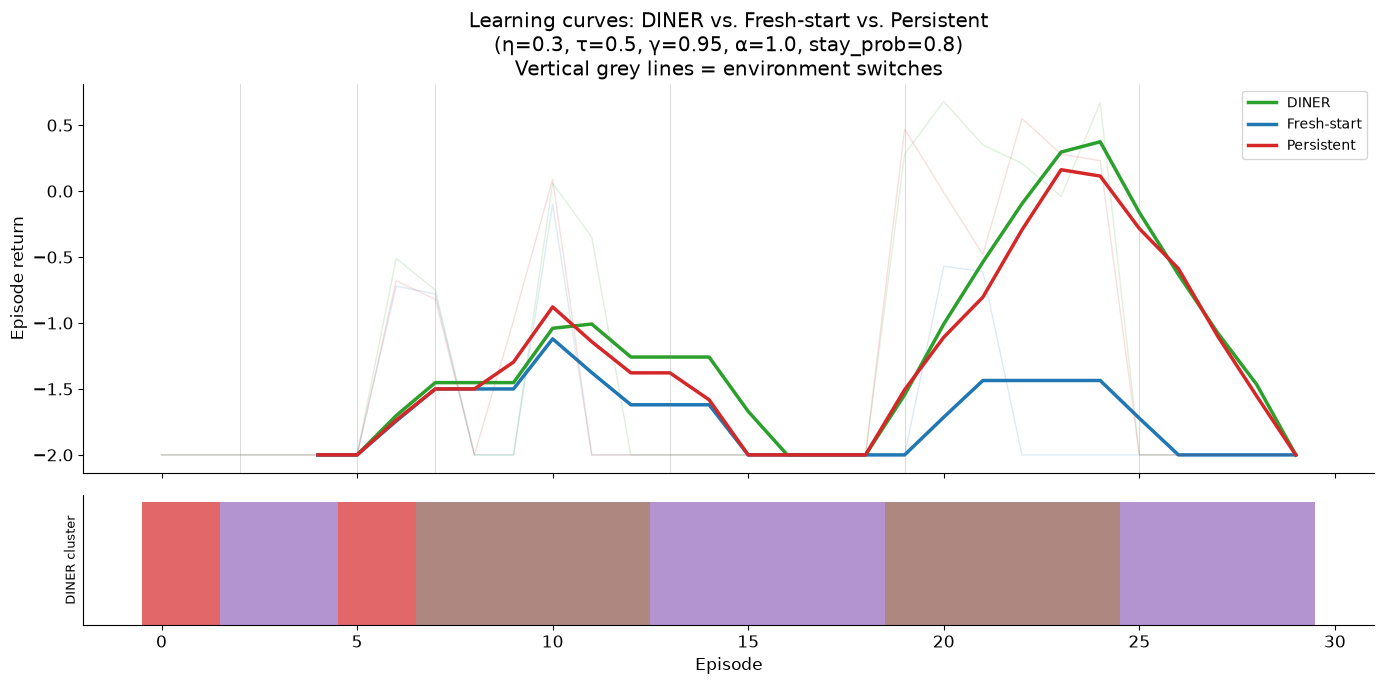

In [9]:
# Compare learning curves across the three true models
w = 5 # smoothing window for plotting
fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True,
                          gridspec_kw={'height_ratios': [3, 1]})

ax1 = axes[0]
for returns, color, label in [
    (diner_returns,      'tab:green',  'DINER'),
    (fresh_returns,      'tab:blue',   'Fresh-start'),
    (persistent_returns, 'tab:red',    'Persistent'),
]:
    smooth = np.convolve(returns, np.ones(w) / w, mode='valid')
    ax1.plot(returns, color=color, alpha=0.15, linewidth=1)
    ax1.plot(range(w - 1, len(returns)), smooth, color=color, linewidth=2.5, label=label)

# Mark environment switches
prev = env_sequence[0]
for ep in range(1, len(env_sequence)):
    if env_sequence[ep] != prev:
        ax1.axvline(ep, color='grey', linewidth=0.5, alpha=0.4)
    prev = env_sequence[ep]

ax1.set_ylabel('Episode return')
ax1.set_title('Learning curves: DINER vs. Fresh-start vs. Persistent\n'
              f'(η={TRUE_ETA}, τ={TRUE_TAU}, γ={TRUE_GAMMA}, α={TRUE_ALPHA}, stay_prob={STAY_PROB})\n'
              'Vertical grey lines = environment switches')
ax1.legend(fontsize=10)

# DINER cluster assignments
ax2 = axes[1]
cluster_colors = ['tab:red', 'tab:purple', 'tab:brown', 'tab:cyan']
for ep, k in enumerate(cluster_assignments):
    ax2.bar(ep, 1, color=cluster_colors[k % len(cluster_colors)], alpha=0.7, width=1)
ax2.set_yticks([]); ax2.set_xlabel('Episode')
ax2.set_ylabel('DINER cluster', fontsize=9)

plt.tight_layout(); plt.show()

---
## 5. Parameter Recovery

**Procedure:**
1. Sample true $(\eta^*, \tau^*, \gamma^*, \alpha^*)$ from a grid $^1$
2. Simulate DINER with those parameters on your environment design
3. Fit the model (MLE via `fit_diner_full`) and compare all four recovered parameters to true values
4. Plot recovered vs. true (good recovery falls near the diagonal)

This tests whether your experimental design supports **parameter identifiability** within DINER. Some potential failure cases:
- **r(η) is low**: learning rate not identifiable. This often occurs when there are too few episodes, or mazes are solved too quickly for different η values to leave distinct traces 
- **r(τ) is low**: temperature not identifiable. This occurs when Q-values are near-uniform, so softmax probabilities don't vary much with τ. This usually points to broader issues with the learning process.
- **r(γ) is low**: discount factor not identifiable. This can be the case when episodes are short and sparse rewards make the distant-future contribution negligible. Try building mazes that require longer paths.
- **r(α) is low**: CRP concentration not identifiable. This can be the case when the number of environment switches is too small for the clustering prior to matter

$^1$ Note that which distribution you use here depends on the context. If you have strong priors based on previous studies, you can sample your parameters from that. Or if you have already collected human data, you will want to use your empirical parameter distribution, for instance, by simulating one synthetic "participant" for each real participant. This will allow you specify that parameter recovery works in the parameter range we expect/observe in human participants.


**Exercise 5.1.** Run the mini-recovery below. Is r > 0.8 for all four parameters? (Probably not with the default settings, which are to prioritize a fast compiling notebook). 

**Exercise 5.2.** Re-run with `N_EPISODES = 20`. Which parameters suffer most with fewer data?

In [10]:
%%time
# Parameter recovery: random uniform sampling over the 4-parameter space
# Uniform sampling gives wide coverage of the parameter space with few points.
# These are set low to allow the notebook to compile quickly.
# Increase them when iterating for robustness:
N_RECOVERY  = 5    # increase to 20–50 for stable correlation estimates
n_restarts  = 1    # increase to 3–5 for more reliable MLE convergence
maxiter     = 500  # increase to 2000–5000 for higher-quality MLE solutions

rng_rec = np.random.default_rng(seed=2026)

# Hand-picked ranges to ensure recovery is neither trivially easy nor impossibly hard.
# Adjust as needed, but keep ranges reasonable for the model and task.
eta_samples   = rng_rec.uniform(0.05, 0.50, N_RECOVERY)   # η ∈ (0.05, 0.50)
tau_samples   = rng_rec.uniform(0.15, 1.50, N_RECOVERY)   # τ ∈ (0.15, 1.50)
gamma_samples = rng_rec.uniform(0.75, 0.98, N_RECOVERY)   # γ ∈ (0.75, 0.98)
alpha_samples = rng_rec.uniform(0.20, 3.00, N_RECOVERY)   # α ∈ (0.20, 3.00)

param_samples = list(zip(eta_samples, tau_samples, gamma_samples, alpha_samples))
print(f'Testing {N_RECOVERY} randomly sampled parameter combinations')
print()

mini_results = []
for i, (true_eta, true_tau, true_gamma, true_alpha) in enumerate(param_samples):
    seq = generate_sticky_env_sequence(env_names, N_EPISODES, stay_prob=STAY_PROB, seed=i * 7)
    _, _, trajs = simulate_diner(
        seq, envs, crp_alpha=true_alpha, eta=true_eta, gamma=true_gamma,
        tau=true_tau, planning_steps=PLANNING, n_probe=N_PROBE, seed=i * 7,
    )
    r = fit_diner_full(seq, envs, trajs, planning_steps=PLANNING, n_restarts=n_restarts, seed=2026,
                       maxiter=maxiter)
    mini_results.append((true_eta, true_tau, true_gamma, true_alpha,
                         r['eta'], r['tau'], r['gamma'], r['crp_alpha']))
    print(f'  [{i+1}/{N_RECOVERY}] '
          f'η:{true_eta:.2f}→{r["eta"]:.3f}  '
          f'τ:{true_tau:.2f}→{r["tau"]:.3f}  '
          f'γ:{true_gamma:.2f}→{r["gamma"]:.3f}  '
          f'α:{true_alpha:.2f}→{r["crp_alpha"]:.3f}')

print('\nParameter recovery complete.')

Testing 5 randomly sampled parameter combinations

  [1/5] η:0.13→0.125  τ:1.22→1.835  γ:0.97→0.935  α:2.51→0.395
  [2/5] η:0.34→0.213  τ:1.37→1.358  γ:0.96→1.000  α:1.46→0.599
  [3/5] η:0.26→0.362  τ:0.39→0.396  γ:0.90→0.893  α:1.15→0.702
  [4/5] η:0.22→0.220  τ:1.03→0.762  γ:0.92→0.802  α:0.98→0.626
  [5/5] η:0.21→0.797  τ:0.55→0.156  γ:0.87→0.001  α:0.83→0.000

Parameter recovery complete.
CPU times: user 2min 26s, sys: 590 ms, total: 2min 27s
Wall time: 2min 27s


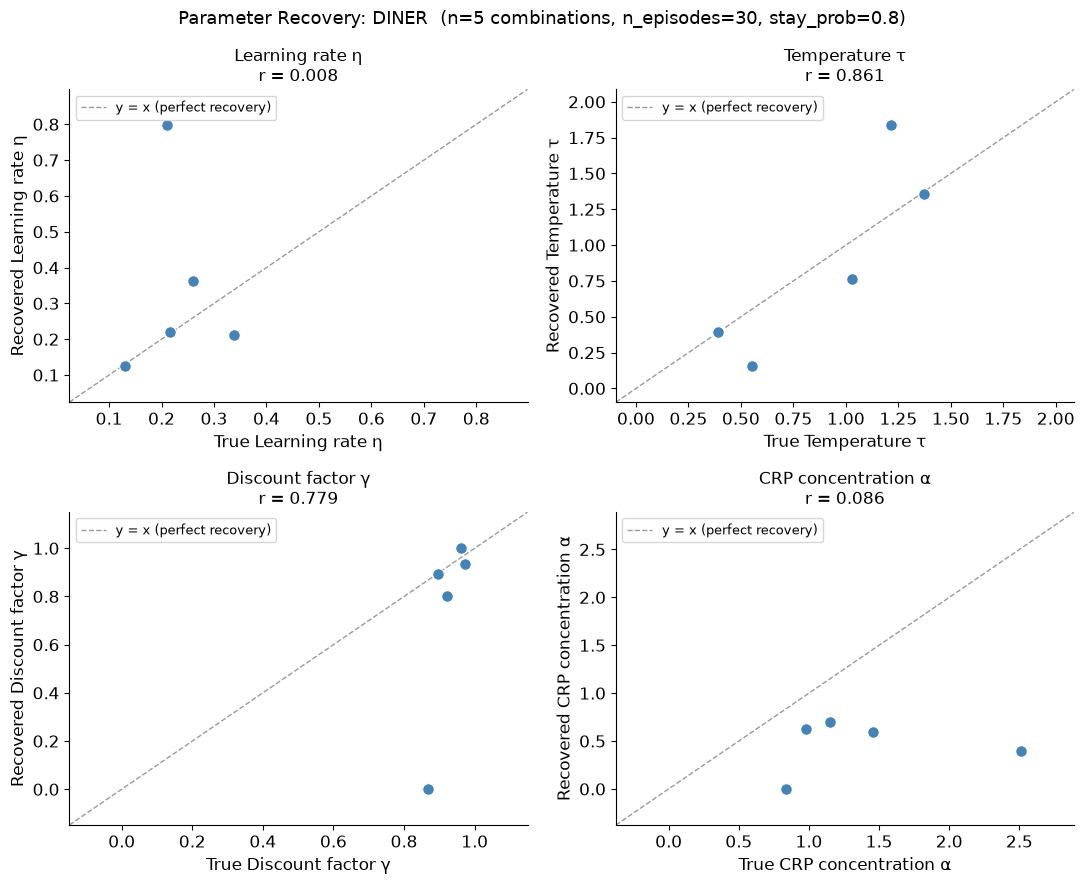

Recovery quality  (r = Pearson correlation, higher = better):
  η: r=0.008  [✗ poor]
  τ: r=0.861  [~ ok]
  γ: r=0.779  [~ ok]
  α: r=0.086  [✗ poor]
Don't read too much into these results before you increase N_RECOVERY, n_restarts, and maxiter to achieve more reliable estimates


In [11]:
true_etas   = [r[0] for r in mini_results]
true_taus   = [r[1] for r in mini_results]
true_gammas = [r[2] for r in mini_results]
true_alphas = [r[3] for r in mini_results]
rec_etas    = [r[4] for r in mini_results]
rec_taus    = [r[5] for r in mini_results]
rec_gammas  = [r[6] for r in mini_results]
rec_alphas  = [r[7] for r in mini_results]

#Note that these correlations will be very underpowered with only 5 points. You should increase N_RECOVERY to at least 20-50 for more reliable estimates of recovery quality.
r_eta   = np.corrcoef(true_etas,   rec_etas)[0, 1]
r_tau   = np.corrcoef(true_taus,   rec_taus)[0, 1]
r_gamma = np.corrcoef(true_gammas, rec_gammas)[0, 1]
r_alpha = np.corrcoef(true_alphas, rec_alphas)[0, 1]

def make_lim(true, rec, pad_frac=0.15):
    """Dynamic axis limits that include all true and recovered values."""
    lo = min(min(true), min(rec))
    hi = max(max(true), max(rec))
    pad = (hi - lo) * pad_frac if hi > lo else 0.1 # extends range of axis limits
    return lo - pad, hi + pad

fig, axes = plt.subplots(2, 2, figsize=(11, 9))
param_info = [
    (axes[0, 0], true_etas,   rec_etas,   'Learning rate η',      r_eta),
    (axes[0, 1], true_taus,   rec_taus,   'Temperature τ',        r_tau),
    (axes[1, 0], true_gammas, rec_gammas, 'Discount factor γ',    r_gamma),
    (axes[1, 1], true_alphas, rec_alphas, 'CRP concentration α',  r_alpha),
]
for ax, true, rec, label, r_val in param_info:
    lim = make_lim(true, rec)
    ax.scatter(true, rec, s=70, color='steelblue', edgecolors='white', linewidth=0.8, zorder=3)
    ax.plot(lim, lim, 'k--', linewidth=1, alpha=0.4, label='y = x (perfect recovery)')
    ax.set_xlabel(f'True {label}')
    ax.set_ylabel(f'Recovered {label}')
    ax.set_xlim(*lim); ax.set_ylim(*lim)
    ax.set_title(f'{label}\nr = {r_val:.3f}', fontsize=12)
    ax.legend(fontsize=9)

fig.suptitle(f'Parameter Recovery: DINER  (n={len(mini_results)} combinations, '
             f'n_episodes={N_EPISODES}, stay_prob={STAY_PROB})', fontsize=13)
plt.tight_layout(); plt.show()


print('Recovery quality  (r = Pearson correlation, higher = better):')
for name, r_val in [('η', r_eta), ('τ', r_tau), ('γ', r_gamma), ('α', r_alpha)]:
    status = '✓ good' if r_val > 0.9 else ('~ ok' if r_val > 0.7 else '✗ poor')
    print(f'  {name}: r={r_val:.3f}  [{status}]')
print("Don't read too much into these results before you increase N_RECOVERY, n_restarts, and maxiter to achieve more reliable estimates")

---
## 6. Model Recovery

Now we ask whether **model comparison** can correctly identify which model generated a dataset. For simplicity, we will use Maximum Likelihood Estimation (MLE) over the entire dataset (for each 'participant'), and use BIC to penalize for model complexity:

### BIC (Bayesian Information Criterion)

$$\text{BIC} = k \ln n - 2\hat{\ell}$$

where $k$ is the number of free parameters in the model, $n$ is the total number of observations, and $\hat{\ell}$ is the maximum log-likelihood.  **Lower BIC = better fit.**

The three models differ in their number of free parameters:

| Model | Free parameters | $k$ | Fitting function |
|---|---|---|---|
| **DINER** | η, τ, γ, α | 4 | `fit_diner_full` |
| **Fresh-start** | η, τ, γ | 3 | `fit_model` |
| **Persistent** | η, τ, γ | 3 | `fit_model` |

Fresh-start and Persistent each have 3 free parameters because γ controls how the discount of future rewards, and different values can fit the data better or worse. DINER incurs an additional BIC penalty for α ($k=4$ vs $k=3$), so it must achieve meaningfully better fit to win. 

Technically, all models could also have the number of planning steps as a free parameter, and DINER could also include the probe limit. However, for simplicity and feasibility here (and also in commonly in real scientific settings), we will bracket these out for now and simply treat them as fixed (planning = 5, probe_limit = 10). If any of the parameters don't result in yield good parameter recovery (e.g., α), this could also justify moving them from a free parameter to a fixed parameter. 

### Fitting via optimization

We fit each model using Nelder-Mead optimization starting from multiple random initial points. In the cell below, we are only simulating 3 synthetic participants (`N_SIMS=3`) and we set `n_restarts=1` and `maxiter=500` to keep runtime short when compiling the notebook. For more reliable estimates, increase these variables when iterating on your own time.

### Procedure
For each of the 3 generating models:
1. Simulate 5 datasets using true parameters **from the correct true simulator** (i..e, 5 synthetic participants)
2. Fit all 3 candidate models to each dataset via optimisation
3. Pick the winner (lowest BIC)
4. Build the confusion matrix P(winning model | simulating model)

**Before running:** What do you predict the confusion matrix will look like with your current design? Write your prediction in the markdown cell below, then check it.

**Exercise 6.1.** After running, which off-diagonal errors occur most often? Does this match the theoretical prediction from Part 2?  
**Exercise 6.2.** Does DINER still win when fitting its own data despite the extra BIC penalty?


### My prediction for the confusion matrix *(edit this cell)*

- **DINER data** → I expect ___ to win because...
- **Fresh-start data** → I expect ___ to win because...
- **Persistent data** → I expect ___ to win because...

*(One useful prediction: if environments switch too rarely, DINER ≈ Persistent, as they both accumulate Q-values within long runs. If they switch too often, DINER ≈ Fresh-start, since both only see each environment briefly.)*

In [12]:
%%time
# ── Model recovery ─────────────────────────────────────────────────────────────
# Parameter counts:  DINER k=4 (η,τ,γ,α)  |  Fresh-start k=3 (η,τ,γ)  |  Persistent k=3 (η,τ,γ)
#
# These are set low to allow the notebook to compile quickly.
# Increase them when iterating for robustness:
N_SIMS      = 3    # increase to 10+ for stable confusion matrix estimates
n_restarts  = 1    # increase to 5–10 for more reliable MLE convergence
maxiter     = 500  # increase to 2000–5000 for higher-quality MLE solutions
# ────────────────────────────────────────────────────────────────────────────────

MODEL_NAMES = ['diner', 'fresh_start', 'persistent']

confmat = np.zeros((3, 3), dtype=int)  # rows = true model, cols = fitted model

for mi, model_name in enumerate(MODEL_NAMES):
    for si in range(N_SIMS):
        seed = 200 + mi * 100 + si
        seq = generate_sticky_env_sequence(env_names, N_EPISODES, stay_prob=STAY_PROB, seed=seed)

        if model_name == 'diner':
            _, _, trajs = simulate_diner(
                seq, envs, crp_alpha=TRUE_ALPHA, eta=TRUE_ETA, gamma=TRUE_GAMMA,
                tau=TRUE_TAU, planning_steps=PLANNING, n_probe=N_PROBE, seed=seed)
        elif model_name == 'fresh_start':
            _, trajs = simulate_fresh_start(
                seq, envs, eta=TRUE_ETA, gamma=TRUE_GAMMA,
                tau=TRUE_TAU, planning_steps=PLANNING, seed=seed)
        else:
            _, trajs = simulate_persistent(
                seq, envs, eta=TRUE_ETA, gamma=TRUE_GAMMA,
                tau=TRUE_TAU, planning_steps=PLANNING, seed=seed)

        r_d = fit_diner_full(seq, envs, trajs, planning_steps=PLANNING, n_restarts=n_restarts, seed=seed,
                             maxiter=maxiter)
        r_f = fit_model(loglik_fresh_start, seq, envs, trajs, planning_steps=PLANNING,
                        n_restarts=n_restarts, seed=seed, maxiter=maxiter)
        r_p = fit_model(loglik_persistent,  seq, envs, trajs, planning_steps=PLANNING,
                        n_restarts=n_restarts, seed=seed, maxiter=maxiter)

        n = r_d["n_steps"]
        bics = [
            compute_bic(r_d["negloglik"], 4, n),
            compute_bic(r_f["negloglik"], 3, n),
            compute_bic(r_p["negloglik"], 3, n),
        ]
        winner = int(np.argmin(bics))
        confmat[mi, winner] += 1
        print(f"  {model_name:12s} sim {si+1}: BIC  D={bics[0]:.0f}  F={bics[1]:.0f}  P={bics[2]:.0f}"
              f"  → {MODEL_NAMES[winner]}")

print(f'\nConfusion matrix  ({N_SIMS} sims/model, rows=true, cols=selected):')
print(confmat)

  diner        sim 1: BIC  D=13557  F=13600  P=13589  → diner
  diner        sim 2: BIC  D=14041  F=14096  P=14096  → diner
  diner        sim 3: BIC  D=15222  F=15247  P=15240  → diner
  fresh_start  sim 1: BIC  D=15361  F=15353  P=15353  → fresh_start
  fresh_start  sim 2: BIC  D=16485  F=16476  P=16476  → fresh_start
  fresh_start  sim 3: BIC  D=16021  F=16010  P=16012  → fresh_start
  persistent   sim 1: BIC  D=15889  F=15880  P=15712  → persistent
  persistent   sim 2: BIC  D=15658  F=15660  P=15606  → persistent
  persistent   sim 3: BIC  D=15409  F=15403  P=15383  → persistent

Confusion matrix  (3 sims/model, rows=true, cols=selected):
[[3 0 0]
 [0 3 0]
 [0 0 3]]
CPU times: user 9min 49s, sys: 2.18 s, total: 9min 51s
Wall time: 9min 51s


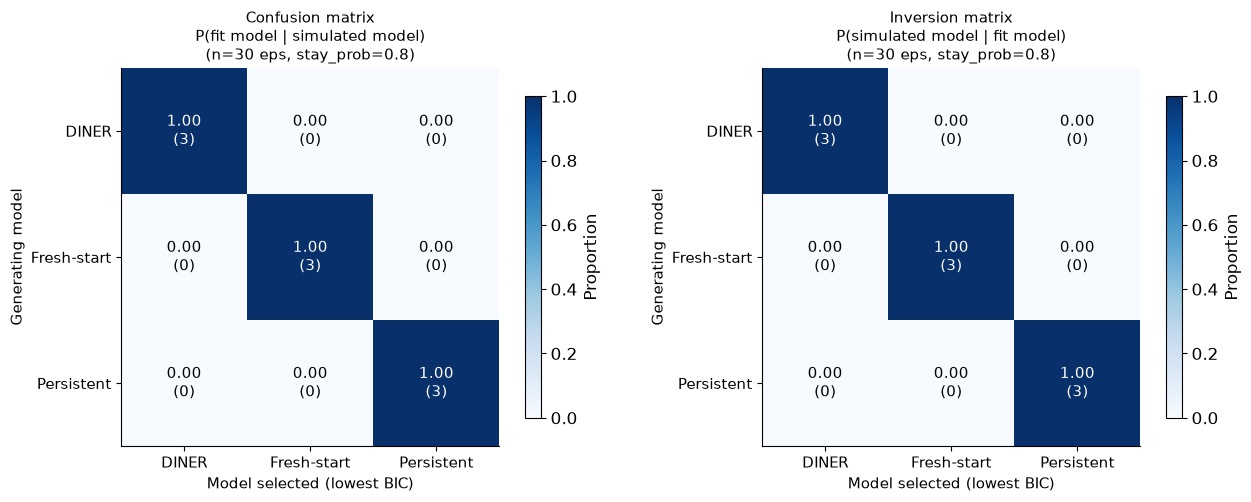

Mean diagonal accuracy (confusion matrix): 1.00
→ Good recovery! Your design reliably discriminates the models.

Inversion matrix interpretation:
  Each column answers: "If I fit this model and it won, what is the probability that the data was generated by that model?"
  P(true=DINER | fit=DINER wins) = 1.00
  P(true=Fresh-start | fit=Fresh-start wins) = 1.00
  P(true=Persistent | fit=Persistent wins) = 1.00


In [13]:
# Plot confusion matrix P(fit|sim) and inversion matrix P(sim|fit) side-by-side
#
# Confusion matrix  (row-normalised): P(fit model | simulated model)
#   How well does model selection recover the true generating model?
#   Diagonal = correct identification rate. Off-diagonal = confusion.
#
# Inversion matrix (column-normalised): P(simulated model | fit model)
#   Given that a model "won", how likely is it to have actually been the true model?
#   This is the Bayesian inversion, directly answering the question a practitioner asks.

model_labels = ['DINER', 'Fresh-start', 'Persistent']
cmat_norm = confmat / confmat.sum(axis=1, keepdims=True)           # P(fit | sim)
imat_norm = confmat / confmat.sum(axis=0, keepdims=True)           # P(sim | fit)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, mat, title, xlabel, ylabel in [
    (axes[0], cmat_norm,
     f'Confusion matrix\nP(fit model | simulated model)\n(n={N_EPISODES} eps, stay_prob={STAY_PROB})',
     'Model selected (lowest BIC)', 'Generating model'),
    (axes[1], imat_norm,
     f'Inversion matrix\nP(simulated model | fit model)\n(n={N_EPISODES} eps, stay_prob={STAY_PROB})',
     'Model selected (lowest BIC)', 'Generating model'),
]:
    im = ax.imshow(mat, cmap='Blues', vmin=0, vmax=1)
    ax.set_xticks(range(3)); ax.set_xticklabels(model_labels, fontsize=11)
    ax.set_yticks(range(3)); ax.set_yticklabels(model_labels, fontsize=11)
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, f'{mat[i,j]:.2f}\n({confmat[i,j]})',
                    ha='center', va='center',
                    color='white' if mat[i,j] > 0.6 else 'black', fontsize=11)
    plt.colorbar(im, ax=ax, label='Proportion', shrink=0.85)

plt.tight_layout(); plt.show()

diag = np.diag(cmat_norm).mean()
print(f'Mean diagonal accuracy (confusion matrix): {diag:.2f}')
if diag < 0.6:
    print('→ Poor recovery. See Section 7 for a diagnosis guide.')
elif diag < 0.85:
    print('→ Acceptable but improvable. Try iterating in Section 7.')
else:
    print('→ Good recovery! Your design reliably discriminates the models.')

print()
print('Inversion matrix interpretation:')
print('  Each column answers: "If I fit this model and it won, what is the probability that the data was generated by that model?"')
for j, name in enumerate(model_labels):
    print(f'  P(true={name} | fit={name} wins) = {imat_norm[j, j]:.2f}')


---
## 7. Iteration, Diagnosis, and Fixes

### Reading the confusion matrix

Off-diagonal patterns tell you *how* the design is failing:

| Off-diagonal pattern | Potential causes | Design fix |
|---|---|---|
| DINER confused with Persistent | Environments too similar, thus DINER never opens new clusters; or stay_prob too high, such that DINER ≈ one long Persistent run | Make envs more divergent or reduce stay_prob |
| Fresh-start confused with DINER | Too few episodes; DINER barely visits any cluster twice, so fresh-start fits equally well | Increase n_episodes |
| Persistent confused with DINER | stay_prob too high; with very long runs, both accumulate Q-values similarly within each run | Decrease stay_prob |
| Fresh-start confused with Persistent | Environments too simple; Q-values converge in 1 episode, so all models produce identical well-learned trajectories | Use longer/harder mazes |
| Everything confused with everything | Not enough data, or environments too easy to solve | More episodes AND harder environments |

### Iteration checklist

Before re-running, work through this checklist:

- [ ] **Probe separability** (Part 1): can DINER distinguish all environments?
- [ ] **Behaviour divergence** (Part 4): do the three model learning curves look different?
- [ ] **Parameter recovery** (Part 5): Do we achieve good correlations for all DINER parameters?
- [ ] **Model recovery** (Part 6): Do we have strong diagonals in the confusion matrix? Does the inversion matrix ensure that if DINER wins, we have good reason to believe it also generated the data?

If all four pass, you've found a good experimental design. Record it in the tracker below.

**Exercise 7.1.** Change `stay_prob` to 0.5 and re-run Parts 6–7. What changes?  
**Exercise 7.2.** Double `N_EPISODES` to 120. Does this help most with parameter or model recovery?  
**Exercise 7.3.** Redesign the environments so that each has its goal in a *completely different corner* and walls that force travel in exactly one cardinal direction. Does this improve the confusion matrix?

In [14]:
# ── Iteration log ─────────────────────────────────────────────────────────────
# Instructions:
#   1. After running Sections 1–7 with your design, edit MY_NOTE below.
#   2. Run this cell (Shift+Enter) to record the current results automatically.
#   3. Iterate: tweak your design, re-run Sections 1–7, update MY_NOTE, re-run here.
#
# The log persists in memory as long as the kernel is running.
# To start fresh: run  iteration_log = []  in a new cell, then re-run this cell.

try:
    iteration_log                  # preserve existing log across re-runs
except NameError:
    iteration_log = []

MY_NOTE = 'baseline'               # edit this, then rerun this cell

# Auto-capture current design results -----------------------------------------
try:
    entry = (STAY_PROB, N_EPISODES, len(env_names),
             r_eta, r_tau, r_gamma, r_alpha, diag, MY_NOTE)
    iteration_log.append(entry)
    print(f'Iteration {len(iteration_log)} logged:  '
          f'stay={STAY_PROB}, n={N_EPISODES}, envs={len(env_names)}')
    print(f'  r_η={r_eta:.2f}  r_τ={r_tau:.2f}  r_γ={r_gamma:.2f}  r_α={r_alpha:.2f}  '
          f'diag={diag:.2f}  | {MY_NOTE!r}')
except NameError as e:
    print(f'Cannot log yet; run Sections 5 and 6 first.  (Missing: {e})')

# Plot progress if we have at least 2 entries ---------------------------------
if len(iteration_log) < 2:
    if len(iteration_log) == 1:
        print('(Run at least one more iteration to see the progress plot.)')
else:
    iters = range(1, len(iteration_log) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    ax1.plot(iters, [r[3] for r in iteration_log], 'o-', color='steelblue', label='η  (r)')
    ax1.plot(iters, [r[4] for r in iteration_log], 's-', color='crimson',   label='τ  (r)')
    ax1.plot(iters, [r[5] for r in iteration_log], '^-', color='darkorange', label='γ  (r)')
    ax1.plot(iters, [r[6] for r in iteration_log], 'D-', color='forestgreen', label='α  (r)')
    ax1.axhline(0.9, color='grey', linestyle='--', alpha=0.5, label='target 0.9')
    ax1.set_ylim(0, 1.05); ax1.set_xlabel('Design iteration')
    ax1.set_ylabel('Pearson r'); ax1.set_title('Parameter recovery'); ax1.legend(fontsize=9)
    ax1.set_xticks(list(iters))

    ax2.plot(iters, [r[7] for r in iteration_log], 'o-', color='tab:green')
    ax2.axhline(0.8, color='grey', linestyle='--', alpha=0.5, label='target 0.8')
    ax2.set_ylim(0, 1.05); ax2.set_xlabel('Design iteration')
    ax2.set_ylabel('Mean diagonal'); ax2.set_title('Model recovery'); ax2.legend(fontsize=9)
    ax2.set_xticks(list(iters))

    plt.suptitle('Recovery quality across design iterations', fontsize=13)
    plt.tight_layout(); plt.show()

    print('\nIteration log:')
    for i, row in enumerate(iteration_log, 1):
        print(f'  {i}: stay={row[0]}, n={row[1]}, envs={row[2]}, '
              f'r_η={row[3]:.2f} r_τ={row[4]:.2f} r_γ={row[5]:.2f} r_α={row[6]:.2f}  '
              f'diag={row[7]:.2f}  | {row[8]!r}')


Iteration 1 logged:  stay=0.8, n=30, envs=3
  r_η=0.01  r_τ=0.86  r_γ=0.78  r_α=0.09  diag=1.00  | 'baseline'
(Run at least one more iteration to see the progress plot.)


---
## 8. Extensions

The exercises below introduce complications that arise when fitting real data, and open-ended design challenges for the rest of the day. Pick whichever is most interesting, since each are self-contained.

---
### Extension A: Likelihood Surface Visualisation

The 2D likelihood surface tells you *why* parameter recovery succeeds or fails. A sharp unimodal peak near the true parameters is ideal. A ridge (elongated peak) means the two parameters are correlated (i.e., the data cannot fully separate them).

**Exercise A.1.** Run the cell below for your current design. Is the peak sharp?  
**Exercise A.2.** Re-run with 20 episodes. Does the surface flatten?  
**Exercise A.3.** *(Stretch)* Plot the likelihood surface for the *Fresh-start* model on DINER-generated data. Where is its peak? Does it coincide with the true DINER parameters?

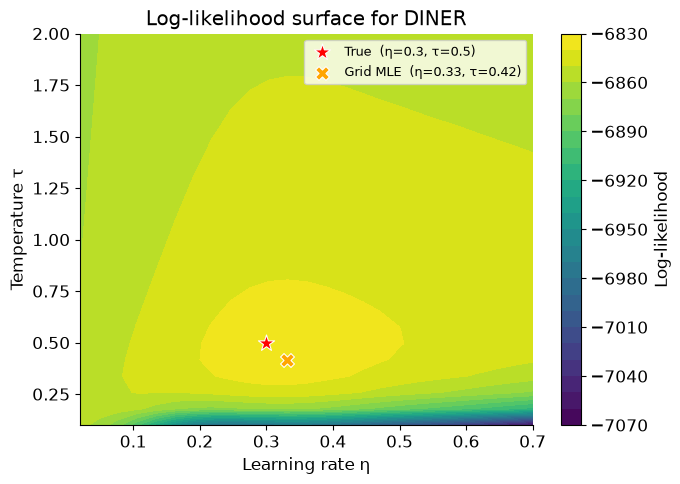

A sharp, round peak near the red star = good identifiability.
An elongated ridge = parameters are correlated and more data is needed or different design.
Note that transforming the parameter space can improve identifiability (e.g., log transformation of τ).


In [15]:
# Extension A: 2D likelihood surface (η vs τ)

# ── Parameters for this extension ─────────────────────────────────────────────
EXT_A_GAMMA    = TRUE_GAMMA  # γ, held fixed while sweeping η and τ
EXT_A_PLANNING = PLANNING    # planning steps
EXT_A_TRUE_ETA = TRUE_ETA    # η, marked as red star on the plot
EXT_A_TRUE_TAU = TRUE_TAU    # τ, marked as red star on the plot
# ──────────────────────────────────────────────────────────────────────────────

# takes ~1-2 min
eta_vals = np.linspace(0.02, 0.70, 25)
tau_vals = np.linspace(0.10, 2.0,  25)

LL = np.zeros((len(tau_vals), len(eta_vals)))
for i, tau in enumerate(tau_vals):
    for j, eta in enumerate(eta_vals):
        LL[i, j] = loglik_diner(
            env_sequence, envs, diner_trajs,
            eta=eta, gamma=EXT_A_GAMMA, tau=tau,
            planning_steps=EXT_A_PLANNING,
            cluster_assignments=cluster_assignments,
        )

fig, ax = plt.subplots(figsize=(7, 5))
cp = ax.contourf(eta_vals, tau_vals, LL, levels=25, cmap='viridis')
plt.colorbar(cp, ax=ax, label='Log-likelihood')
ax.scatter([EXT_A_TRUE_ETA], [EXT_A_TRUE_TAU], c='red', s=150, zorder=5,
           marker='*', edgecolors='white', linewidth=0.8,
           label=f'True  (η={EXT_A_TRUE_ETA}, τ={EXT_A_TRUE_TAU})')
best_j, best_i = np.unravel_index(np.argmax(LL), LL.shape)
ax.scatter([eta_vals[best_i]], [tau_vals[best_j]], c='orange', s=100, zorder=5,
           marker='X', edgecolors='white', linewidth=0.8,
           label=f'Grid MLE  (η={eta_vals[best_i]:.2f}, τ={tau_vals[best_j]:.2f})')
ax.set_xlabel('Learning rate η'); ax.set_ylabel('Temperature τ')
ax.set_title('Log-likelihood surface for DINER')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f'A sharp, round peak near the red star = good identifiability.')
print(f'An elongated ridge = parameters are correlated and more data is needed or different design.')
print(f'Note that transforming the parameter space can improve identifiability (e.g., log transformation of τ).')


---
### Extension B: Which Parameters Does DINER Need?

The main exercises use `fit_diner_full` with all four free parameters (η, τ, γ, α). But two of them may not be worth estimating:

- **α**: if environments are probe-distinguishable, the CRP fingerprinting already determines cluster assignments regardless of α's exact value, making it unidentifiable from behaviour.
- **γ**: fixing γ avoids one optimisation dimension, but only if the fixed value is approximately correct. Using the wrong γ distorts the Q-value discount structure and degrades fit.

This extension runs four fits in sequence and compares their BIC, revealing the cost and benefit of each parameter:

| Fit | Free params | k | When is this appropriate? |
|---|---|---|---|
| Full DINER | η, τ, γ, α | 4 | Default |
| α fixed | η, τ, γ | 3 | α is unidentifiable in deterministic environments |
| γ, α fixed at TRUE | η, τ | 2 | You know γ from prior work |
| γ fixed at WRONG value, α fixed | η, τ | 2 | Misspecification test |

**Questions:**  
- Does fixing α hurt BIC? If not, should DINER count as k=3 in Section 6?  
- How much worse is the wrong-γ fit compared to the correct γ?  
- At what point does misspecifying γ cost more than just estimating it freely?

In [16]:
# Extension B: Parameter ablation

# ── Parameters for this extension ─────────────────────────────────────────────
EXT_B_ALPHA       = TRUE_ALPHA  # α held fixed in reduced fits
EXT_B_GAMMA       = TRUE_GAMMA  # γ correct fixed value
EXT_B_GAMMA_WRONG = 0.70        # deliberately wrong γ (misspecification)
EXT_B_PLANNING    = PLANNING
EXT_B_N_PROBE     = N_PROBE
# ──────────────────────────────────────────────────────────────────────────────

# Precompute cluster assignments once (used by all α-fixed fits)
asgn_fixed = compute_cluster_assignments(
    env_sequence, envs, crp_alpha=EXT_B_ALPHA, n_probe=EXT_B_N_PROBE, seed=0
)

# Fit 1: Full DINER (k=4) with all four free parameters 
r4 = fit_diner_full(
    env_sequence, envs, diner_trajs,
    planning_steps=EXT_B_PLANNING, n_restarts=2, seed=42, maxiter=500,
)

# Fit 2: with α fixed (k=3), but optimizing η, τ, γ
r3 = fit_model(
    loglik_diner, env_sequence, envs, diner_trajs,
    planning_steps=EXT_B_PLANNING, n_restarts=2, seed=42, maxiter=500,
    free_gamma=True, cluster_assignments=asgn_fixed,
)

# Fit 3: with γ and α both fixed at TRUE (k=2), optimizing η, τ only
r2_correct = fit_model(
    loglik_diner, env_sequence, envs, diner_trajs,
    gamma=EXT_B_GAMMA, planning_steps=EXT_B_PLANNING,
    n_restarts=2, seed=42, maxiter=500,
    free_gamma=False, cluster_assignments=asgn_fixed,
)

# Fit 4: γ fixed at plausible-but-wrong value (sensitivity analysis), α fixed at a misspecified value (k=2)
# This tells you how robust the model comparison is to differences in γ.
# In practice, γ is sometimes fixed by convention (e.g., from a prior study) rather than estimated 
r2_wrong = fit_model(
    loglik_diner, env_sequence, envs, diner_trajs,
    gamma=EXT_B_GAMMA_WRONG, planning_steps=EXT_B_PLANNING,
    n_restarts=2, seed=42, maxiter=500,
    free_gamma=False, cluster_assignments=asgn_fixed,
)

n            = r4['n_steps']
bic4         = compute_bic(r4['negloglik'],         4, n)
bic3         = compute_bic(r3['negloglik'],         3, n)
bic2_correct = compute_bic(r2_correct['negloglik'], 2, n)
bic2_wrong   = compute_bic(r2_wrong['negloglik'],   2, n)

print(f'{"Model":<42}  {"k":>2}  {"BIC":>8}  {"ΔBIC vs k=4":>12}')
print('─' * 70)
print(f'{"Full DINER  (η, τ, γ, α free)":<42}  {4:>2}  {bic4:>8.1f}  {"—":>12}')
print(f'{"α fixed     (η, τ, γ free)":<42}  {3:>2}  {bic3:>8.1f}  {bic3 - bic4:>+12.1f}')
print(f'{"γ, α fixed at TRUE  (η, τ free)":<42}  {2:>2}  {bic2_correct:>8.1f}  {bic2_correct - bic4:>+12.1f}')
print(f'{"γ={:.2f} sensitivity, α fixed  (η, τ free)":<42}  {2:>2}  {bic2_wrong:>8.1f}  {bic2_wrong - bic4:>+12.1f}'.format(EXT_B_GAMMA_WRONG))
print()
print(f'Generating parameters:')
print(f'  η={TRUE_ETA:.3f}  τ={TRUE_TAU:.3f}  γ={TRUE_GAMMA:.3f}  α={TRUE_ALPHA:.3f}')
print()
print(f'Recovered parameters:')
print(f'  k=4: η={r4["eta"]:.3f}  τ={r4["tau"]:.3f}  γ={r4["gamma"]:.3f}  α={r4["crp_alpha"]:.3f}')
print(f'  k=3: η={r3["eta"]:.3f}  τ={r3["tau"]:.3f}  γ={r3["gamma"]:.3f}  (α fixed)')
print(f'  k=2: η={r2_correct["eta"]:.3f}  τ={r2_correct["tau"]:.3f}  (γ, α fixed at true values)')
print(f'  k=2: η={r2_wrong["eta"]:.3f}  τ={r2_wrong["tau"]:.3f}  (γ sensitivity test {EXT_B_GAMMA_WRONG})')
print()
print('Potential follow-up: re-run model recovery (Section 6) with an ablated version of DINER:')
print('Does DINER now win more reliably against Fresh-start and Persistent?')


Model                                        k       BIC   ΔBIC vs k=4
──────────────────────────────────────────────────────────────────────
Full DINER  (η, τ, γ, α free)                4   13702.8             —
α fixed     (η, τ, γ free)                   3   13694.3          -8.5
γ, α fixed at TRUE  (η, τ free)              2   13685.8         -17.0
γ=0.70 sensitivity, α fixed  (η, τ free)   2   13697.0          -5.8

Generating parameters:
  η=0.300  τ=0.500  γ=0.950  α=1.000

Recovered parameters:
  k=4: η=0.329  τ=0.418  γ=0.938  α=0.874
  k=3: η=0.329  τ=0.418  γ=0.938  (α fixed)
  k=2: η=0.321  τ=0.429  (γ, α fixed at true values)
  k=2: η=0.800  τ=0.319  (γ sensitivity test 0.7)

Potential follow-up: re-run model recovery (Section 6) with an ablated version of DINER:
Does DINER now win more reliably against Fresh-start and Persistent?


---
### Extension C: Multi-Block Designs

The single-block design above is fast to simulate, but limits how much data each participant contributes. Real experiments often run **multiple blocks**, each with a fresh set of environments, thus providing more data about the early stages of learning that are particularly useful for distinguishing models.

### Why multiple blocks?

Each block is an **independent restart**: all agents begin with fresh Q-tables, and DINER begins with no cluster history. Pooling trajectories across blocks (for each participant) increases the number of independent likelihood terms without changing the nature of the comparison. The early-episode portion of the learning curve, where the models diverge most, is observed multiple times, thus magnifying the BIC difference between them.

### Real-world timing constraints

Keep the total experiment time within budget. If each episode takes ~60–90 s:

| Design | Episodes/block | Blocks | Total episodes | Approx. time |
|---|---|---|---|---|
| Single block (current) | 30 | 1 | 30 | ~30–45 min ✓ |
| Two short blocks | 20 | 2 | 40 | ~40–60 min (borderline) |
| Two full blocks | 30 | 2 | 60 | ~60–90 min ✗ |

The key trade-off: more blocks require reducing episodes per block to stay within the time budget.

### Your task

In the cells below, `simulate_multiblock` is already defined for you. Your job is to use it inside the **Section 5 and 6 loops** by replacing the single-episode `simulate_diner / simulate_fresh_start / simulate_persistent` calls with `simulate_multiblock(model_name, N_BLOCKS, EPISODES_PER_BLOCK, ...)`. You can then compare the results to your single-block baseline.

**Exercise C.1.** Adapt the **parameter recovery** loop from Section 5: replace `simulate_diner(seq, ...)` with `simulate_multiblock('diner', ...)`. Do the correlations r(η), r(τ), r(γ), r(α) improve compared to the single-block result already stored in `r_eta`, `r_tau`, `r_gamma`, `r_alpha`?

**Exercise C.2.** Adapt the **model recovery** loop from Section 6: make the same substitution inside the `confmat` loop (all three models). Does the confusion-matrix diagonal improve over the single-block `diag`?

**Exercise C.3.** *(Stretch)* Set `EXT_C_N_BLOCKS = 4` and `EXT_C_EPISODES_PER_BLOCK = 15` and re-run both exercises. Does four short blocks within a 40-minute budget improve recovery further?

In [17]:
# ── Parameters for this extension ─────────────────────────────────────────────
EXT_C_N_BLOCKS           = 2    # number of blocks
EXT_C_EPISODES_PER_BLOCK = 20   # episodes per block (total ≤ 40 for ~40-min experiment)
EXT_C_ETA                = TRUE_ETA    # η
EXT_C_TAU                = TRUE_TAU    # τ
EXT_C_GAMMA              = TRUE_GAMMA  # γ
EXT_C_ALPHA              = TRUE_ALPHA  # α (CRP concentration)
EXT_C_PLANNING           = PLANNING    # planning steps
# ──────────────────────────────────────────────────────────────────────────────

# Aliases used by the simulation cells below
N_BLOCKS           = EXT_C_N_BLOCKS
EPISODES_PER_BLOCK = EXT_C_EPISODES_PER_BLOCK

print(f'Multi-block design: {N_BLOCKS} blocks × {EPISODES_PER_BLOCK} episodes '
      f'= {N_BLOCKS * EPISODES_PER_BLOCK} total episodes per model')
print(f'Estimated task time: {N_BLOCKS * EPISODES_PER_BLOCK * 1.25:.0f}–'
      f'{N_BLOCKS * EPISODES_PER_BLOCK * 1.5:.0f} min')

Multi-block design: 2 blocks × 20 episodes = 40 total episodes per model
Estimated task time: 50–60 min


In [18]:
# Helper for Exercises C.1 and C.2. Run this cell first, then complete the loops below.
# Each block is an independent restart: fresh Q-tables and, for DINER, fresh cluster state.
# Trajectories are concatenated across blocks for fitting.

def simulate_multiblock(model_name, n_blocks, eps_per_block, env_names, envs,
                        eta, gamma, tau, crp_alpha, planning, base_seed=0):
    """Simulate a multi-block experiment for one model.

    Each block is an independent learning episode (fresh state for all agents).
    Returns (all_seqs, all_trajs) concatenated across blocks.
    """
    all_seqs, all_trajs = [], []

    for b in range(n_blocks):
        seed_b = base_seed + b * 7
        seq = generate_sticky_env_sequence(
            env_names, eps_per_block, stay_prob=STAY_PROB, seed=seed_b)

        if model_name == 'diner':
            _, _, trajs = simulate_diner(
                seq, envs, crp_alpha=crp_alpha, eta=eta, gamma=gamma,
                tau=tau, planning_steps=planning, seed=seed_b)
        elif model_name == 'fresh_start':
            _, trajs = simulate_fresh_start(
                seq, envs, eta=eta, gamma=gamma, tau=tau,
                planning_steps=planning, seed=seed_b)
        else:  # persistent
            _, trajs = simulate_persistent(
                seq, envs, eta=eta, gamma=gamma, tau=tau,
                planning_steps=planning, seed=seed_b)

        all_seqs.extend(seq)
        all_trajs.extend(trajs)

    return all_seqs, all_trajs


print(f'simulate_multiblock defined. Ready for Exercises C.1 and C.2.')
print(f'Current multi-block design: {N_BLOCKS} blocks × {EPISODES_PER_BLOCK} episodes '
      f'= {N_BLOCKS * EPISODES_PER_BLOCK} total episodes per participant')

simulate_multiblock defined. Ready for Exercises C.1 and C.2.
Current multi-block design: 2 blocks × 20 episodes = 40 total episodes per participant


In [19]:
# Exercise C.1 — Multi-block parameter recovery
# Adapt Section 5's loop: replace simulate_diner(seq, ...) with simulate_multiblock('diner', ...).
# The sampling and fitting logic stays the same — only the data-generation step changes.

N_RANDOM_C = 5   # increase to 20–50 for stable correlation estimates

true_etas_c, true_taus_c, true_gammas_c, true_alphas_c = [], [], [], []
rec_etas_c,  rec_taus_c,  rec_gammas_c,  rec_alphas_c  = [], [], [], []

rng_rec_c = np.random.default_rng(seed=3000)

for si in range(N_RANDOM_C):
    seed_c  = 3000 + si
    t_eta   = rng_rec_c.uniform(0.05, 0.50)
    t_tau   = rng_rec_c.uniform(0.15, 1.50)
    t_gamma = rng_rec_c.uniform(0.75, 0.98)
    t_alpha = rng_rec_c.uniform(0.20, 3.00)

    # YOUR CODE: generate multi-block trajectories for DINER.
    # Hint: call simulate_multiblock('diner', N_BLOCKS, EPISODES_PER_BLOCK, env_names, envs,
    #                                 eta=t_eta, gamma=t_gamma, tau=t_tau,
    #                                 crp_alpha=t_alpha, planning=EXT_C_PLANNING, base_seed=seed_c)
    seq_c, trajs_c = ...

    res = fit_diner_full(seq_c, envs, trajs_c,
                         planning_steps=EXT_C_PLANNING, n_restarts=1, seed=seed_c, maxiter=500)

    true_etas_c.append(t_eta);    rec_etas_c.append(res['eta'])
    true_taus_c.append(t_tau);    rec_taus_c.append(res['tau'])
    true_gammas_c.append(t_gamma); rec_gammas_c.append(res['gamma'])
    true_alphas_c.append(t_alpha); rec_alphas_c.append(res['crp_alpha'])

    print(f'  [{si+1}/{N_RANDOM_C}] '
          f'η:{t_eta:.2f}→{res["eta"]:.3f}  '
          f'τ:{t_tau:.2f}→{res["tau"]:.3f}  '
          f'γ:{t_gamma:.2f}→{res["gamma"]:.3f}  '
          f'α:{t_alpha:.2f}→{res["crp_alpha"]:.3f}')

r_eta_c   = np.corrcoef(true_etas_c,   rec_etas_c)[0, 1]
r_tau_c   = np.corrcoef(true_taus_c,   rec_taus_c)[0, 1]
r_gamma_c = np.corrcoef(true_gammas_c, rec_gammas_c)[0, 1]
r_alpha_c = np.corrcoef(true_alphas_c, rec_alphas_c)[0, 1]

print()
print(f'Multi-block ({N_BLOCKS}×{EPISODES_PER_BLOCK}):  '
      f'r_η={r_eta_c:.2f}  r_τ={r_tau_c:.2f}  r_γ={r_gamma_c:.2f}  r_α={r_alpha_c:.2f}')
print(f'Single-block (1×{N_EPISODES}):   '
      f'r_η={r_eta:.2f}   r_τ={r_tau:.2f}   r_γ={r_gamma:.2f}   r_α={r_alpha:.2f}')

TypeError: cannot unpack non-iterable ellipsis object

In [20]:
# Exercise C.2: Multi-block model recovery
# Adapt Section 6's `confmat` loop by replacing simulate_* with simulate_multiblock
# The fitting and BIC logic stays the same, but only the data-generation step needs to be changed

N_SIMS_C = 3   # increase to 10+ for stable confusion matrix estimates

confmat_c = np.zeros((3, 3), dtype=int) 

for mi, model_name in enumerate(MODEL_NAMES):
    for si in range(N_SIMS_C):
        seed_c = 5000 + mi * 100 + si

        # YOUR CODE: generate multi-block trajectories for the current model.
        # Hint: call simulate_multiblock(model_name, N_BLOCKS, EPISODES_PER_BLOCK,
        #                                env_names, envs, eta=TRUE_ETA, gamma=TRUE_GAMMA,
        #                                tau=TRUE_TAU, crp_alpha=TRUE_ALPHA,
        #                                planning=EXT_C_PLANNING, base_seed=seed_c)
        seq_c, trajs_c = ...

        r_d = fit_diner_full(seq_c, envs, trajs_c, planning_steps=EXT_C_PLANNING,
                             n_restarts=1, seed=2026, maxiter=500)
        r_f = fit_model(loglik_fresh_start, seq_c, envs, trajs_c,
                        planning_steps=EXT_C_PLANNING, n_restarts=1, seed=2026, maxiter=500)
        r_p = fit_model(loglik_persistent,  seq_c, envs, trajs_c,
                        planning_steps=EXT_C_PLANNING, n_restarts=1, seed=2026, maxiter=500)

        n_c = r_d['n_steps']
        bics_c = [
            compute_bic(r_d['negloglik'], 4, n_c),  # DINER: k=4
            compute_bic(r_f['negloglik'], 3, n_c),  # Fresh-start: k=3
            compute_bic(r_p['negloglik'], 3, n_c),  # Persistent: k=3
        ]
        winner_c = int(np.argmin(bics_c))
        confmat_c[mi, winner_c] += 1
        print(f'  {model_name:12s} sim {si+1}: BIC  D={bics_c[0]:.0f}  '
              f'F={bics_c[1]:.0f}  P={bics_c[2]:.0f}  → {MODEL_NAMES[winner_c]}')

cmat_c_norm = confmat_c / confmat_c.sum(axis=1, keepdims=True)
diag_c = np.diag(cmat_c_norm).mean()

print()
print(f'Multi-block ({N_BLOCKS}×{EPISODES_PER_BLOCK}): mean diagonal = {diag_c:.2f}')
print(f'Single-block (1×{N_EPISODES}):   mean diagonal = {diag:.2f}')

TypeError: cannot unpack non-iterable ellipsis object

In [21]:
# Comparison summary and iteration log
# Run after completing Exercises C.1 and C.2.

print(f'Parameter recovery  (multi-block minus single-block):')
print(f'  Δr_η = {r_eta_c - r_eta:+.2f}   Δr_τ = {r_tau_c - r_tau:+.2f}')
print(f'  Δr_γ = {r_gamma_c - r_gamma:+.2f}   Δr_α = {r_alpha_c - r_alpha:+.2f}')
print(f'Model recovery improvement:  Δdiag = {diag_c - diag:+.2f}')

# Log to the Section 7 tracker so the multi-block design appears in the progress plot.
MY_NOTE_C = f'multi-block {N_BLOCKS}x{EPISODES_PER_BLOCK}'
try:
    entry_c = (STAY_PROB, N_BLOCKS * EPISODES_PER_BLOCK, len(env_names),
               r_eta_c, r_tau_c, r_gamma_c, r_alpha_c, diag_c, MY_NOTE_C)
    iteration_log.append(entry_c)
    print(f'\nLogged to iteration_log as iteration {len(iteration_log)}.')
    print('Re-run the iteration log cell in Section 7 to see the updated progress plot.')
except NameError:
    print('\nRun Section 7 first to initialise iteration_log, then re-run this cell.')

Parameter recovery  (multi-block minus single-block):


NameError: name 'r_eta_c' is not defined

---
### Extension D: Stochastic Environments

In the current DINER implementation, the environments are **deterministic**, meaning the same action from the same state always leads to the same next state. This has two important consequences:

1. **alpha is unidentifiable** (as Extension B shows): One contradictory probe transition always  creates a new cluster, regardless of alpha, since the likelihood is binary (old cluster = true vs. false). Thus, the CRP prior parameterized by alpha doesn't really influence cluster assignments.

2. **The Dyna model is exact**: `model[(s, a)] = (s', r)` stores a single observed transition, with sampled transitions during replay always reproducing the same outcome.

Introducing stochasticity changes both:

- **Probes become distributions**: `P(s' | s, a)` rather than `s' = f(s, a)`. Thus, two environments should merge if their transition distributions are similar and split if they differ. This decision is now graded, not binary, with **alpha controling the splitting threshold**, thus making it genuinely identifiable from behaviour.

- **The model learns transition probabilities** (e.g., via a delta rule): rather than storing a single observed next state, the agent will learn a distribution $P(s' \mid s, a)$ over possible next states. This can be updated after each transition using a simple prediction-error rule (Antonov & Dayan, 2025; Keßler et al., 2026):

$$P(s' \mid s, a) \leftarrow P(s' \mid s, a) + \eta_m \bigl(\delta(s' \mid s, a) - P(s' \mid s, a)\bigr)$$

where $\delta(s' \mid s, a) = 1$ if $s'$ was actually reached (and 0 for all other next states), and $\eta_m$ is a model learning rate. This is analogous to the Delta rule, but applied to transition probabilities: the agent adjusts their belief about $P(s' \mid s, a)$ toward the observed outcome by a fraction $\eta_m$ on each step. During planning, the agent samples next states from the learned distribution rather than replaying a single fixed transition.

The scaffold below identifies the three functions to modify. Implement them, then test two predictions: (1) cluster accuracy increases with more probe samples per step; (2) alpha becomes recoverable in parameter recovery (unlike in Extension B).

**Exercise D.1.** Implement `collect_probe_transitions_stochastic` and verify cluster assignments are still correct when transition noise is low.

**Exercise D.2.** Sweep `n_samples_per_step` from 1 to 20. At what point does cluster accuracy plateau?

**Exercise D.3.** *(Stretch)* Re-run parameter recovery (Section 5) after implementing stochastic probes. Does alpha become recoverable?

In [22]:
# Extension D scaffold: extending DINER to stochastic environments
# Implement the three functions below, then substitute them into
# simulate_diner and compute_cluster_assignments in recovery.py.

import numpy as np


# ── Key change 1: probe fingerprint via delta rule ────────────────────────────
def collect_probe_transitions_stochastic(env, n_probe, n_samples_per_step=5, eta_m=0.3):
    """
    Build a probe fingerprint by applying the delta rule to repeated samples.

    For each probe step, the same action is tried n_samples_per_step times from
    the same state (resetting between samples). Each observed transition
    (state, action) -> s_prime updates the estimated distribution P(s'|s,a) via:

        P(s'|s,a) <- P(s'|s,a) + eta_m * (delta(s'|s,a) - P(s'|s,a))

    where delta(s'|s,a) = 1 for the observed s', 0 for all other next states.
    After n_samples_per_step updates the values are explicitly normalised so the
    fingerprint holds a valid probability distribution for comparison to observed state transitions.

    Returns fingerprint: dict mapping (state, action) -> {s_prime: probability}
    over the n_probe (state, action) pairs visited during the probe.
    """
    # TODO:
    #   fingerprint = {}   # maps (s, a) -> {s': P(s'|s,a)}
    #   state = env.start_pos
    #   for _ in range(n_probe):
    #       action = env.action_space.sample()
    #       dist = {}
    #       for _ in range(n_samples_per_step):
    #           env.reset()
    #           s_prime, _, _, _, _ = env.step(action)
    #           # Delta rule for observed s' (delta = 1)
    #           prev = dist.get(s_prime, 0.0)
    #           dist[s_prime] = prev + eta_m * (1.0 - prev)
    #       # Normalise: 
    #       total = sum(dist.values())
    #       fingerprint[(state, action)] = {s: p / total for s, p in dist.items()}
    #       state = max(dist, key=dist.get)   # advance via modal next state
    #   return fingerprint
    raise NotImplementedError


# ── Key change 2: graded JSD distance + Bayesian cluster assignment ───────────
def probe_distance_stochastic(fingerprint, probe):
    """
    Replace the binary has_probe_contradiction() with a graded dissimilarity using
    Jensen-Shannon distance (JSD).

    The JSD is computed over the **next-state distribution** P(·|s,a) for each
    (state, action) pair that appears in both the stored cluster fingerprint and
    the new probe, i.e., the n_probe probe steps where both the cluster and the
    current agent have seen that (s,a). This gives one JSD value per shared
    probe step, and the function returns their mean (0 = identical, 1 = maximally
    different).

        JSD(P, Q) = 0.5 * KL(P || M) + 0.5 * KL(Q || M),  M = 0.5 * (P + Q)

    where P = P_cluster(·|s,a) and Q = P_probe(·|s,a) are distributions over
    next states s', and KL is computed only over the union of next states with
    non-zero probability in either distribution.

    Once distances are computed, cluster assignment follows the CRP posterior
    (as described in Day 1 Block 2), replacing the binary consistency check with
    a graded likelihood:

        log P(probe | cluster k) = sum_{(s,a) in probe} log P_k(s_prime | s, a) # probe likelihood

        log posterior(k) ∝ log n_k - log(n + alpha)          # CRP prior
                         + log P(probe | cluster k)           # probe likelihood

    The new-cluster option carries prior weight alpha / (n + alpha) and an
    uninformative (uniform) transition likelihood. Assign to the cluster with
    the highest posterior (or equivalently, open a new cluster when the new-
    cluster posterior exceeds all existing clusters).
    """
    # TODO: for each (state, action) key in probe that also appears in fingerprint:
    #   build probability vectors P and Q over the union of their next-state keys
    #   compute JSD(P, Q) using the formula above
    # return mean JSD across all shared (state, action) pairs
    raise NotImplementedError


# ── Key change 3: delta-rule model update ────────────────────────────────────
def update_model_stochastic(model_transitions, model_rewards, s, a, s_prime, r, eta_m):
    """
    Update P(s'|s,a) using the delta  rule:

        P(s'|s,a) <- P(s'|s,a) + eta_m * (delta(s'|s,a) - P(s'|s,a))

    where delta(s'|s,a) = 1 for the observed next state, 0 for all others.

    model_transitions : dict mapping (s, a, s') -> float; default 0 for unseen triples
    model_rewards     : dict mapping (s, a)      -> float, running mean reward
    eta_m             : model learning rate (independent of the Q-value rate eta)

    Note: the stored values do not sum to exactly 1 at every step (they converge
    asymptotically to the true distribution). Normalise at query time before
    sampling next states during planning.
    """
    # TODO:
    #   # Delta rule for the observed next state (delta = 1)
    #   key_obs = (s, a, s_prime)
    #   prev = model_transitions.get(key_obs, 0.0)
    #   model_transitions[key_obs] = prev + eta_m * (1.0 - prev)
    #   #Normalize the distribution for (s, a) over all s' (optional, can be done at query time)
    #   total = sum(model_transitions.get((s, a, s2), 0.0) for s2 in states)
    #   if total > 0:
    #       for s2 in states:
    #           key = (s, a, s2)
    #           model_transitions[key] /= total
    #
    #   # Running mean reward
    #   n = sum(1 for k in model_transitions if k[0] == s and k[1] == a)
    #   prev_r = model_rewards.get((s, a), 0.0)
    #   model_rewards[(s, a)] = prev_r + (r - prev_r) / max(n, 1)
    raise NotImplementedError


print("Stochastic DINER scaffold loaded.")
print("Implement the three functions above, then integrate them into")
print("recovery.py by modifying simulate_diner and compute_cluster_assignments.")
print()
print("Key predictions to test after implementation:")
print("  1. Cluster accuracy improves with n_samples_per_step")
print("  2. Alpha becomes recoverable in parameter recovery (unlike in Extension B), because")
print("     the CRP prior now has a graded effect on cluster splitting via the posterior")


Stochastic DINER scaffold loaded.
Implement the three functions above, then integrate them into
recovery.py by modifying simulate_diner and compute_cluster_assignments.

Key predictions to test after implementation:
  1. Cluster accuracy improves with n_samples_per_step
  2. Alpha becomes recoverable in parameter recovery (unlike in Extension B), because
     the CRP prior now has a graded effect on cluster splitting via the posterior


---
### Extension E: Open Design Exploration

You've now completed the core analysis and explored two targeted questions. Use the rest of the session to pursue your own scientific question. All the code you need is already in Sections 1–7, which can be re-run with new parameter values.

**Direction 1: Environmental volatility**  
Sweep `STAY_PROB` across [0.4, 0.6, 0.8, 0.95]. Where is model recovery hardest — at very high or very low volatility, and why? Use the model recovery loop from Section 6 as a template.

**Direction 2: Number of environments**  
Add a 4th environment (revisit Exercise 1). Does more environments make model recovery easier or harder? What does it do to DINER's cluster assignments and BIC penalty?

**Direction 3: More episodes**  
Double `N_EPISODES` to 60. Which parameters improve most? Does the confusion-matrix diagonal cross 0.9?

**Direction 4: Harder mazes**  
Redesign environments so optimal paths are longer (25+ steps). Does this make the three models more distinguishable? Does it change which parameters are easiest to recover?

---
## Summary

Today you took on the harder question: not just *can* we fit this model, but *what experimental design lets us reliably tell models apart?*

| Concept | Key takeaway |
|---|---|
| **Divergent environments** | Optimal policies between alternative models should conflict across environments |
| **Probe separability** | Wall structure should differ across environments to allow for the behavioral probes to identify them |
| **Parameter recovery** | Do estimated parameters correlate with the true generating parameters? This is necessary to ensure each parameter is identifiable in the experimental setting|
| **Model recovery** | Are the different candidate models distinguishable, i.e., do we recover the true generative model? If a given model wins, do we have high confidence it also generated the data (or does it tend to overfit other models)? |
| **Design iteration** | No single design works a priori; iterating on the environmental stimuli with model and parameter recovery analyses can improve the chances of a successful experiment|